# Screening fixes for model-agreement false alarms (iteration-5 FREEZE, Part A demo)

This notebook is a runnable demo of the **iteration-5 FREEZE experiment**. The experiment asks whether a *gold-free*
faithfulness score for NL→FOL translations can be improved. The score is **cross-family solver consensus**: a candidate
formula is suspicious when translations of the same sentence produced by *other* model families are **not**
logically equivalent to it.

* **V0 = `c_score_align`** (the frozen incumbent): `1 − share of other-family peer translations that agree with the candidate`.
  Two formulas agree when they are z3-equivalent, either exactly or after a vocabulary alignment ("eqmv": exact / align / gran).
* Five **label-free rescorings** are computed from the same pairwise eqmv matrix:
  * **V1**: plurality-normalised. Support is measured against the largest peer class.
  * **V2**: reliability-weighted. Each family gets an out-of-fold, Dawid–Skene-style weight.
  * **V3** = V1 + V2.
  * **V4**: a cross-fitted logistic model over (exact-only disagreement, aligned disagreement).
  * **V5** = V3 on a cheap 3-family pool.
* A **pre-registered rule** picks a winner only if its AUROC on long, heavily conditioned sentences (LONG-strat) beats
  V0 by ≥ +0.015, it is ≥ V0 on L25, and it is ≥ V0 − 0.01 on CTRL. Otherwise the result is **"NONE: V0 stands"**.

The original `method.py` is an **orchestrator**: it runs about 25 `src/*.py` scripts in a pre-registered order. This
notebook keeps the orchestrator's code and step table. It then runs the **Part A** steps inline, reusing the artifact's
own code (`freeze/consensus_variants.py`, `src/stats.py`, `src/labels.py`, `src/score_variants.py`, `src/fit_v4.py`,
`src/screen.py`, `src/select_rule.py`) on a **100-sentence stratified subset of dataset E**. That subset has 25
sentences each from L25, L20, EXC and CTRL. The solver matrix was precomputed with z3 by an earlier evaluation, so no
solver or API calls are needed here.

Parts B, GGB and C are not re-run: they need z3 symbol-map searches and paid Gemini calls. Their frozen results are
shown at the end.

*All numbers are development numbers on dataset E. On a 100-sentence subset they are noisy; the full-run values are
shown next to them.*

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

## Imports
The first block is `method.py`'s import block, unchanged. The second block holds the imports of the `src/` and
`freeze/` modules that run inline below, plus matplotlib for the final figure.

In [2]:
# ---- method.py (original import block)
from __future__ import annotations

import argparse
import os
import subprocess
import sys
import time
from pathlib import Path

from loguru import logger

# ---- imports of the inlined src/ + freeze/ modules (consensus_variants, stats, labels, score_variants, fit_v4, screen, select_rule)
import hashlib
import json
import math
from collections import Counter, defaultdict
from typing import Sequence

import numpy as np
import pandas as pd
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression

# ---- notebook-only: visualisation
import matplotlib.pyplot as plt

## Data loading
`mini_demo_data.json` holds one dataset, `E_demo_sentences`, with 100 sentences. Each example contains:

* `matrix_record`: eval-2's label-free pairwise record for the sentence. It has `nodes` (distinct canonical formulas
  and the candidate rows that produced them), `pairs` `[i, j, eq, kind, secs]` with z3/eqmv verdicts, and the greedy
  `cliques`.
* `rows`: every candidate translation of the sentence. Each row has the label-free fields the sealed scorer may read
  (`exp5_row_key`, `family`, `fold_E`, `c_score_align` = frozen V0, …). It also has the **labels** (`y_R_AB`,
  `error_ops`, …), which are joined only after scoring, plus the full run's frozen `predict_*` values.

`metadata` holds the frozen family weights, the frozen V4 coefficients and the full-run reference numbers.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_e4aqYfQhdCkX/round-5/experiment-14/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["source"])
print("sentences:", data["metadata"]["n_sentences"], "| candidate rows:", data["metadata"]["n_rows"])

dataset E (700 sentences) -> 100-sentence stratified demo subset; matrix = eval-2 pairwise_classes_E.jsonl
sentences: 100 | candidate rows: 1275


## Config
These are all the tunable parameters. The original values are in the comments; the numbers from `src/common.py` and
`src/select_rule.py` are used unchanged. `N_SENTENCES` takes the first N sentences of the demo subset. The subset is
interleaved by stratum, so any prefix stays balanced across L25/L20/EXC/CTRL.

In [5]:
N_SENTENCES = 100    # sentences of the demo subset to use (max 100 here; the original run uses all 700 of dataset E)
B = 2000             # sentence-cluster bootstrap replicates for CIs (original: B = 2000, src/common.py)
B_STAB = 500         # selection-stability resamples (original: 500, src/select_rule.py)
B_NULL = 200         # label-permutation null replicates (original: 200, src/select_rule.py)
SEED = 20260924      # bootstrap seed (original, src/common.py); stability uses SEED+1, null SEED+2
USE_FROZEN_FAMILY_WEIGHTS = True  # True: V2/V3/V5 use the frozen out-of-fold weights estimated on all 700 E sentences
                                  # (reproduces the full run's per-row scores); False: re-estimate them on this subset

# pre-registered constants (src/common.py, src/select_rule.py) — not meant to be tuned
STRATA = ("L25", "L20", "EXC", "CTRL")
LONG = ("L25", "L20", "EXC")
NEUTRAL_C = 0.6266243516243516  # exp-5 prereg imputation.neutral.c_score_align (|P| < 2 rows)

## The orchestrator (`method.py`)
This is the original step table: `(stage, script + args, cwd, marker output)`. Each stage is run as a subprocess under
`PYTHONHASHSEED=0` and skipped when its marker exists. The notebook has no `src/` directory, so `main()` is not called.
The Part A steps marked **▶ inline** below run in the following cells with the scripts' own code. The other steps need
the 36 MB of upstream inputs, z3 map searches or OpenRouter calls; their frozen results are read from `metadata`.

In [6]:
ROOT = Path.cwd()  # notebook: was Path(__file__).resolve().parent
SRC = ROOT / "src"
PY = sys.executable

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(ROOT / "logs").mkdir(exist_ok=True)
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")

# (stage, script + args, cwd, output that marks the step done)
STEPS = [
    ("A", ["copy_inputs.py"], SRC, "inputs_manifest.json"),
    ("A", ["step0_gates.py"], SRC, "results/gate_G0.json"),
    ("A", ["prereg_improve.py"], SRC, "prereg_improve.json"),
    ("A", ["make_row_index.py"], SRC, "results/row_index_labelfree.jsonl"),
    ("A", ["score_variants.py"], SRC, "results/scores_E_variants.jsonl"),
    ("A", ["fit_v4.py"], SRC, "results/scores_E_V4.jsonl"),
    ("A", ["screen.py"], SRC, "results/screen_E.json"),
    ("A", ["select_rule.py"], SRC, "results/selection_E.json"),
    ("A", ["freeze_part_a.py"], SRC, "freeze/selection.json"),
    ("B", ["probe.py"], SRC, "results/probe.json"),
    ("B", ["prereg_gg.py"], SRC, "prereg_gg.json"),
    ("B", ["gg_search.py", "all"], SRC, "results/gg_search.jsonl"),
    ("B", ["gg_gates.py", "dev", "v1"], SRC, "results/gg_gates_dev_v1.json"),
    ("B", ["gg_gates.py", "confirm", "v2"], SRC, "results/gg_gates_confirm_v2.json"),
    ("B", ["gg_gloss.py"], SRC, "results/gg_verdicts.json"),
    ("B", ["gg_score.py"], SRC, "results/gg_dev.json"),
    ("B", ["freeze_part_b.py"], SRC, "freeze/gg_gate.json"),
    ("GGB", ["ggb_search.py", "all"], SRC, "results/ggb_search.jsonl"),
    ("GGB", ["ggb_score.py"], SRC, "results/ggb_dev.json"),
    ("C", ["vendor_lib.py"], SRC, "lib/PROVENANCE.json"),
    ("OUT", ["make_outputs.py"], SRC, "method_out.json"),
    ("OUT", ["make_tables.py"], SRC, "tables.md"),
    ("TEST", ["-m", "pytest", "-q", "tests/test_variants.py", "tests/test_gg.py", "tests/test_budget.py"], ROOT, None),
    ("TEST", ["tests/audit_rederive.py"], ROOT, None),
    ("TEST", ["tests/smoke_lib.py"], ROOT, None),
]
NEVER_FORCE = {"prereg_improve.py", "prereg_gg.py", "freeze_part_a.py"}  # immutable writers


@logger.catch(reraise=True)
def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--stage", default="A,B,GGB,C,OUT,TEST")
    ap.add_argument("--force", action="store_true")
    a = ap.parse_args()
    stages = set(a.stage.split(","))
    env = {**os.environ, "PYTHONHASHSEED": "0"}
    for stage, args, cwd, marker in STEPS:
        if stage not in stages:
            continue
        name = args[0]
        if marker and (ROOT / marker).exists() and (not a.force or name in NEVER_FORCE):
            logger.info(f"[{stage}] skip {' '.join(args)} ({marker} exists)")
            continue
        logger.info(f"[{stage}] run {' '.join(args)}")
        t0 = time.time()
        try:
            subprocess.run([PY, *args], cwd=cwd, env=env, check=True)
        except subprocess.CalledProcessError as e:
            logger.error(f"[{stage}] {name} failed with exit code {e.returncode}")
            raise
        logger.info(f"[{stage}] {name} done in {time.time() - t0:.0f}s")


# notebook: show the plan instead of calling main() (no src/ tree here)
INLINE = {"make_row_index.py", "score_variants.py", "fit_v4.py", "screen.py", "select_rule.py"}
for stage, args, cwd, marker in STEPS:
    print(f"[{stage:4s}] {'▶ inline ' if args[0] in INLINE else '  frozen '} {' '.join(args):55s} -> {marker}")

[A   ]   frozen  copy_inputs.py                                          -> inputs_manifest.json
[A   ]   frozen  step0_gates.py                                          -> results/gate_G0.json
[A   ]   frozen  prereg_improve.py                                       -> prereg_improve.json
[A   ] ▶ inline  make_row_index.py                                       -> results/row_index_labelfree.jsonl
[A   ] ▶ inline  score_variants.py                                       -> results/scores_E_variants.jsonl
[A   ] ▶ inline  fit_v4.py                                               -> results/scores_E_V4.jsonl
[A   ] ▶ inline  screen.py                                               -> results/screen_E.json
[A   ] ▶ inline  select_rule.py                                          -> results/selection_E.json
[A   ]   frozen  freeze_part_a.py                                        -> freeze/selection.json
[B   ]   frozen  probe.py                                                -> results/probe.jso

## Scoring functions: `freeze/consensus_variants.py` (verbatim)
These are the pure, gold-free functions frozen under marker M1. Each one takes one sentence's matrix record, indexed by
`build_index`. **Higher score = more likely error.** The peer pool is *leave-own-family-out*: parseable peer rows from
other vendor families. An unparseable candidate scores 1.0, and fewer than 2 peers gives `None` (imputed neutral).

In [7]:
POOL3 = ("deepseek", "microsoft", "openai")
SHRINK = 20.0


# ------------------------------------------------------------------------------------------------ index
def build_index(rec: dict) -> dict:
    """Index one pairwise_classes record. Returns {'sid', 'node_of', 'meta', 'eq', 'kind', 'clique_of'}.
    MEASURES: nothing (data structure). GOLD-FREE: yes. COST: O(#pairs)."""
    eq, kind = {}, {}
    for i, j, e, k, _s in rec["pairs"]:
        eq[(i, j)] = eq[(j, i)] = e
        kind[(i, j)] = kind[(j, i)] = k
    node_of, meta = {}, {}
    for nd in rec["nodes"]:
        for r in nd["rows"]:
            node_of[r["row_key"]] = nd["node_id"]
            meta[r["row_key"]] = r
    clique_of = {}
    for ci, cl in enumerate(rec.get("cliques") or [[nd["node_id"]] for nd in rec["nodes"]]):
        for n in cl:
            clique_of[n] = ci
    return {"sid": rec["sentence_id"], "node_of": node_of, "meta": meta, "eq": eq, "kind": kind, "clique_of": clique_of,
            "nodes": rec["nodes"]}


def agree(ix: dict, a: int, b: int) -> bool:
    """eqmv agreement of two nodes (same node = True; UNKNOWN = False)."""
    return True if a == b else ix["eq"].get((a, b)) is True


def agree_exact(ix: dict, a: int, b: int) -> bool:
    """Aligner-free agreement: same node, or eq True with kind 'exact'."""
    return True if a == b else (ix["eq"].get((a, b)) is True and ix["kind"].get((a, b)) == "exact")


def peers_lofo(ix: dict, row_key: str, families: tuple | None = None, family_key: str = "family") -> list[str]:
    """Peer rows of candidate `row_key`: is_peer, other vendor family, not itself; optionally restricted to `families`.
    MEASURES: the pool. GOLD-FREE: yes."""
    fam = ix["meta"][row_key][family_key]
    out = []
    for rk, m in ix["meta"].items():
        if not m["is_peer"] or m[family_key] == fam or rk == row_key:
            continue
        if families is not None and m[family_key] not in families:
            continue
        out.append(rk)
    return sorted(out)


# ------------------------------------------------------------------------------------------------ V0 / exact
def c_score_align(ix: dict, row_key: str, peers: list[str] | None = None, min_peers: int = 2) -> float | None:
    """V0 = 1 - share of peers eqmv-agreeing. REPRODUCTION ONLY (E2 must use exp-5 byte-identical code for V0).
    MEASURES: disagreement with other-family translations modulo vocabulary alignment. GOLD-FREE: yes."""
    if row_key not in ix["node_of"]:
        return 1.0
    P = peers_lofo(ix, row_key) if peers is None else peers
    if len(P) < min_peers:
        return None
    c = ix["node_of"][row_key]
    return 1 - sum(agree(ix, c, ix["node_of"][p]) for p in P) / len(P)


def c_exact(ix: dict, row_key: str, peers: list[str] | None = None, min_peers: int = 2) -> float | None:
    """1 - share of peers z3-equivalent with identical symbols (no aligner). GOLD-FREE: yes."""
    if row_key not in ix["node_of"]:
        return 1.0
    P = peers_lofo(ix, row_key) if peers is None else peers
    if len(P) < min_peers:
        return None
    c = ix["node_of"][row_key]
    return 1 - sum(agree_exact(ix, c, ix["node_of"][p]) for p in P) / len(P)


# ------------------------------------------------------------------------------------------------ V1 / V3 / V5
def _pn(ix: dict, row_key: str, P: list[str], w: dict | None) -> float:
    c = ix["node_of"][row_key]
    wt = (lambda rk: 1.0) if w is None else (lambda rk: float(w.get(ix["meta"][rk]["family"], 1.0)))
    tot = sum(wt(p) for p in P)
    if tot <= 0:
        return 1.0
    share_a = sum(wt(p) for p in P if agree(ix, c, ix["node_of"][p])) / tot
    if share_a == 0:
        return 1.0
    cls = defaultdict(float)
    for p in P:
        cls[ix["clique_of"][ix["node_of"][p]]] += wt(p)
    max_share = max(cls.values()) / tot
    return 1 - min(1.0, share_a / max_share)


def c_pn(ix: dict, row_key: str, peers: list[str] | None = None, min_peers: int = 2) -> float | None:
    """V1 plurality-normalised consensus: 1 - min(1, share_A / max_class_share) (share_A = 0 -> 1.0).
    MEASURES: how far the candidate's support falls short of the largest peer class (a candidate in the plurality of a
    scattered pool scores 0). GOLD-FREE: yes."""
    if row_key not in ix["node_of"]:
        return 1.0
    P = peers_lofo(ix, row_key) if peers is None else peers
    if len(P) < min_peers:
        return None
    return _pn(ix, row_key, P, None)


def c_pn_rw(ix: dict, row_key: str, weights: dict, peers: list[str] | None = None, min_peers: int = 2) -> float | None:
    """V3 = V1 with family-weighted shares. GOLD-FREE: yes (weights are label-free)."""
    if row_key not in ix["node_of"]:
        return 1.0
    P = peers_lofo(ix, row_key) if peers is None else peers
    if len(P) < min_peers:
        return None
    return _pn(ix, row_key, P, weights)


def c_v5(ix: dict, row_key: str, weights: dict, families: tuple = POOL3) -> float | None:
    """V5 = V3 on the cost-matched 3-pool {deepseek, microsoft, openai} minus own family; >= 1 pool row required
    (eval-2 c_k3 convention: empty pool -> None, imputed neutral downstream). GOLD-FREE: yes."""
    if row_key not in ix["node_of"]:
        return 1.0
    P = peers_lofo(ix, row_key, families=families)
    if len(P) < 1:
        return None
    return _pn(ix, row_key, P, weights)


# ------------------------------------------------------------------------------------------------ V2
def family_weights(indexes: list[dict], fold_of: dict, holdout_fold: int | None, shrink: float = SHRINK) -> dict:
    """Label-free family reliability weights from the pairwise matrix of every sentence NOT in `holdout_fold`
    (holdout_fold None = all sentences). For family f and sentence s (>= 1 peer row of f and >= 1 peer row of another
    family): agr_f(s) = mean over (r in f, q not in f) of A(r, q). a_f = mean_s agr_f(s), n_f = #such sentences,
    abar = mean over all (f, s) of agr_f(s); w_f = (n_f * a_f + shrink * abar) / (n_f + shrink).
    MEASURES: how often a family's translations agree with other families' (a proxy for its reliability, Dawid-Skene
    style, no labels). GOLD-FREE: yes."""
    per = defaultdict(list)
    allv = []
    for ix in indexes:
        if holdout_fold is not None and fold_of[ix["sid"]] == holdout_fold:
            continue
        peers = [rk for rk, m in ix["meta"].items() if m["is_peer"]]
        fams = defaultdict(list)
        for rk in peers:
            fams[ix["meta"][rk]["family"]].append(rk)
        for f, rs in fams.items():
            qs = [q for q in peers if ix["meta"][q]["family"] != f]
            if not rs or not qs:
                continue
            v = sum(agree(ix, ix["node_of"][r], ix["node_of"][q]) for r in rs for q in qs) / (len(rs) * len(qs))
            per[f].append(v)
            allv.append(v)
    abar = sum(allv) / len(allv) if allv else 0.0
    return {f: (len(v) * (sum(v) / len(v)) + shrink * abar) / (len(v) + shrink) for f, v in sorted(per.items())}


def c_rw(ix: dict, row_key: str, weights: dict, peers: list[str] | None = None, min_peers: int = 2) -> float | None:
    """V2 = 1 - sum_{p in P agreeing} w_f(p) / sum_{p in P} w_f(p); families missing from `weights` get weight 1.0
    (never happens on E). GOLD-FREE: yes."""
    if row_key not in ix["node_of"]:
        return 1.0
    P = peers_lofo(ix, row_key) if peers is None else peers
    if len(P) < min_peers:
        return None
    c = ix["node_of"][row_key]
    wt = {p: float(weights.get(ix["meta"][p]["family"], 1.0)) for p in P}
    tot = sum(wt.values())
    if tot <= 0:
        return 1.0
    return 1 - sum(wt[p] for p in P if agree(ix, c, ix["node_of"][p])) / tot


# ------------------------------------------------------------------------------------------------ V4
def c_two_channel(c_exact_v: float | None, c_align_v: float | None, coefs: dict) -> float | None:
    """V4 = sigmoid(b0 + b_exact * c_exact + b_align * c_align). coefs = {'intercept', 'c_exact', 'c_align'}.
    MEASURES: a label-fitted blend of aligner-free and aligned disagreement. GOLD-FREE application (coefficients were fit
    on E labels, OOF in development)."""
    if c_exact_v is None or c_align_v is None:
        return None
    z = coefs["intercept"] + coefs["c_exact"] * c_exact_v + coefs["c_align"] * c_align_v
    return 1 / (1 + math.exp(-z))

## Statistics: `src/stats.py` (verbatim, the parts the screen uses)
* `auroc` is Mann–Whitney AUROC with ties counted ½.
* `strat_auroc` is **within-stratum** AUROC: only (ERROR, CORRECT) pairs from the same source stratum count, which
  removes the effect of stratum composition.
* `SentBoot`, `WAuc` and `WStratAuc` form a sentence-cluster bootstrap. Each replicate is a vector of sentence
  multiplicities, and every score is evaluated on the same replicates, so the Δs are paired.

In [8]:
def auroc(y, s) -> float:
    """Mann-Whitney AUROC, ties counted 1/2 (== sklearn roc_auc_score). nan if one class is empty."""
    y = np.asarray(y)
    s = np.asarray(s, float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def strat_auroc(y, s, stratum) -> float:
    """Within-stratum AUROC: sum_h AUC_h * P_h * N_h / sum_h P_h * N_h (only (ERROR, CORRECT) pairs from the same
    source stratum count), identical to exp 5's strat_auc. Removes the stratum-composition part of pooled AUROC."""
    y = np.asarray(y)
    s = np.asarray(s, float)
    stratum = np.asarray(stratum)
    num = den = 0.0
    for h in np.unique(stratum):
        m = stratum == h
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auroc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


def boot_ci(vals, lo: float = 2.5, hi: float = 97.5) -> list:
    v = np.asarray([x for x in vals if x is not None and not (isinstance(x, float) and math.isnan(x))], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


class WAuc:
    """AUROC under row weights (bootstrap multiplicities); ties = 0.5. Precomputes the score ranking once."""

    def __init__(self, y, s):
        self.y = np.asarray(y, float)
        vals, self.inv = np.unique(np.asarray(s, float), return_inverse=True)
        self.nv = len(vals)

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        W1 = np.bincount(self.inv, weights=w * self.y, minlength=self.nv)
        W0 = np.bincount(self.inv, weights=w * (1 - self.y), minlength=self.nv)
        den = W1.sum() * W0.sum()
        if den <= 0:
            return float("nan")
        cum0 = np.cumsum(W0) - W0
        return float((W1 * (cum0 + 0.5 * W0)).sum() / den)


class WStratAuc:
    """Within-stratum pair AUROC under row weights."""

    def __init__(self, y, s, strata):
        self.y = np.asarray(y, float)
        strata = np.asarray(strata)
        self.parts = [(np.where(strata == st)[0], WAuc(self.y[strata == st], np.asarray(s, float)[strata == st]))
                      for st in np.unique(strata)]

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        num = den = 0.0
        for ix, wa in self.parts:
            ww = w[ix]
            n1 = (ww * self.y[ix]).sum()
            n0 = (ww * (1 - self.y[ix])).sum()
            if n1 > 0 and n0 > 0:
                num += wa(ww) * n1 * n0
                den += n1 * n0
        return num / den if den else float("nan")


class SentBoot:
    """Sentence-cluster bootstrap as multiplicity weights: W[b, i] = #times row i's sentence was drawn in replicate b."""

    def __init__(self, sids, b: int = 2000, seed: int = 0):
        sids = np.asarray(sids)
        self.keys, self.sent_ix = np.unique(sids, return_inverse=True)
        S = len(self.keys)
        rng = np.random.default_rng(seed)
        self.C = np.stack([np.bincount(rng.integers(0, S, S), minlength=S) for _ in range(b)]).astype(float)
        self.B = b

    def W(self, mask=None):
        W = self.C[:, self.sent_ix]
        return W if mask is None else W[:, mask]

## Step `make_row_index.py`: label-free row index
The original writes `results/row_index_labelfree.jsonl` from `per_item_T1.jsonl`. It keeps a whitelist of label-free
fields and **asserts that no label field leaks into it**. Here the rows come from the loaded `data`, restricted to the
first `N_SENTENCES` sentences. The label fields go into a separate `LABEL_ROWS` list, which is joined only after scoring.

In [9]:
examples = data["datasets"][0]["examples"][:N_SENTENCES]
recs = [e["matrix_record"] for e in examples]            # notebook: was jl(MATRIX) (eval-2 pairwise_classes_E.jsonl)
PER_ITEM_ROWS = [r for e in examples for r in e["rows"]]  # notebook: was jl(PER_ITEM) (exp-6 per_item_T1.jsonl)

KEEP = ["canonical_key", "exp5_row_key", "sentence_id", "fold_E", "source_stratum", "family", "system", "pool", "parse_ok",
        "prompt_variant", "c_score_align"]
FORBIDDEN = {"final_label", "y_R_AB", "in_R_AB", "in_R_A", "label_tier", "auto_label", "error_ops", "repair_ops", "reading_choice", "vex"}

rows = []
for r in PER_ITEM_ROWS:
    d = {k: r[k] for k in KEEP}
    d["words"] = r["words"]                 # notebook: per_item_T1 keeps these under r["strata"]
    d["n_conditions"] = r["n_conditions"]
    assert not (set(d) & FORBIDDEN)
    rows.append(d)
print(f"{len(recs)} sentences, {len(rows)} label-free candidate rows")

100 sentences, 1275 label-free candidate rows


## Step `score_variants.py`: label-free, sealed scoring of every row
For every sentence the matrix record is indexed. Folds are `sha1('E_folds_v1|' + sentence_id) % 5`, and the code
asserts that this equals the stored fold. **V2 family weights are estimated out-of-fold**: rows of fold k use weights
fitted on the sentences of the other folds. Each row then gets V0_rep, c_exact, V1, V2, V3, V5 and the 3-pool plain
c. Gate **G1** checks that the re-derived V0 matches the frozen `c_score_align` column to 1e-6, since that column is
rounded to 6 decimals.

Changes for the notebook: the sha256 input hashing, the file writes and the seal file are dropped (there are no files
to seal), and the `len(recs) == 700` assert becomes `N_SENTENCES`. With 100 of 700 sentences, the V2/V3/V5 weights
would be estimated from 1/7 of the data. By default (`USE_FROZEN_FAMILY_WEIGHTS = True`) the frozen out-of-fold
weights from all 700 sentences are used instead, so every per-row score reproduces the full run. Gate G1 is
reported here but on a subset it is only indicative. The few mismatching rows here are among the full run's 24
known mismatches (24/8,469 = 0.28%, G1 passes); they cluster in a few sentences, so a small subset can show a higher
share.

In [10]:
def sha1(s: str) -> str:
    return hashlib.sha1(s.encode()).hexdigest()


def fold_of_sid(sid: str) -> int:
    return int(sha1("E_folds_v1|" + sid), 16) % 5


t0 = time.time()
assert len(recs) == N_SENTENCES  # original: == 700
IX = {r["sentence_id"]: build_index(r) for r in recs}
fold = {}
for r in rows:
    f = fold_of_sid(r["sentence_id"])
    assert f == r["fold_E"], (r["sentence_id"], f, r["fold_E"])
    fold[r["sentence_id"]] = f
for sid in IX:
    fold.setdefault(sid, fold_of_sid(sid))
# V2 weights per holdout fold + full-E
idx_list = [IX[s] for s in sorted(IX)]
W = {k: family_weights(idx_list, fold, k) for k in range(5)}
W_full = family_weights(idx_list, fold, None)
if USE_FROZEN_FAMILY_WEIGHTS:  # notebook: the subset is 1/7 of E, so reuse the full-E out-of-fold weights (results/family_weights.json)
    W = {int(k): v for k, v in data["metadata"]["frozen_family_weights"]["per_fold_holdout"].items()}
logger.info(f"full-E family weights {json.dumps({k: round(v, 4) for k, v in W_full.items()})}")
logger.info(f"(frozen full-run weights, used={USE_FROZEN_FAMILY_WEIGHTS} {json.dumps({k: round(v, 4) for k, v in data['metadata']['frozen_family_weights']['full_E'].items()})})")
out = []
n_mis = n_cmp = 0
mism = []
for r in rows:
    rk, sid = r["exp5_row_key"], r["sentence_id"]
    ix = IX.get(sid)
    rec = {"row_key": rk, "canonical_key": r["canonical_key"], "sentence_id": sid, "fold": fold[sid],
           "stratum": r["source_stratum"], "family": r["family"], "V0_frozen": r["c_score_align"]}
    in_mx = ix is not None and rk in ix["node_of"]
    rec["in_matrix"] = in_mx
    if not in_mx:
        rec.update(V0_rep=1.0, c_exact=1.0, V1=1.0, V2=1.0, V3=1.0, V5=1.0, c3_plain=1.0, n_peers=0, n_peers_3pool=0,
                   coverage_status="UNPARSEABLE")
    else:
        P = peers_lofo(ix, rk)
        P3 = peers_lofo(ix, rk, families=POOL3)
        w = W[fold[sid]]
        rec.update(n_peers=len(P), n_peers_3pool=len(P3), coverage_status="OK" if len(P) >= 2 else "PEER_UNAVAILABLE",
                   V0_rep=c_score_align(ix, rk, P), c_exact=c_exact(ix, rk, P), V1=c_pn(ix, rk, P),
                   V2=c_rw(ix, rk, w, P), V3=c_pn_rw(ix, rk, w, P), V5=c_v5(ix, rk, w),
                   c3_plain=(c_score_align(ix, rk, P3, min_peers=1)))
        rec["V5_imputed"] = rec["V5"] is None
        if rec["V5"] is None:
            rec["V5"] = NEUTRAL_C
        if rec["c3_plain"] is None:
            rec["c3_plain"] = NEUTRAL_C
    if rec["V0_rep"] is not None and rec["V0_frozen"] is not None:
        n_cmp += 1
        if abs(rec["V0_rep"] - rec["V0_frozen"]) > 1e-6:  # per_item_T1 stores 6 decimals
            n_mis += 1
            mism.append({"row_key": rk, "rep": rec["V0_rep"], "frozen": rec["V0_frozen"], "n_peers": rec["n_peers"]})
    out.append(rec)
g1 = {"n_compared": n_cmp, "n_mismatch": n_mis, "mismatch_share": n_mis / n_cmp, "rule": "<= 0.005 of rows with |V0_rep - V0_frozen| > 1e-6 (the frozen column is rounded to 6 decimals)",
      "pass": n_mis / n_cmp <= 0.005, "mismatches": mism[:100],
      "n_rows_peer_unavailable": sum(r["coverage_status"] == "PEER_UNAVAILABLE" for r in out),
      "n_rows_unparseable": sum(r["coverage_status"] == "UNPARSEABLE" for r in out)}
logger.info(f"G1 label-free part: {n_mis}/{n_cmp} = {n_mis / n_cmp:.4%} mismatch -> pass={g1['pass']}")
logger.info(f"coverage: {g1['n_rows_unparseable']} UNPARSEABLE, {g1['n_rows_peer_unavailable']} PEER_UNAVAILABLE (counted, never dropped)")
SCORES_E_VARIANTS = out  # notebook: was written to results/scores_E_variants.jsonl + sha256 seal
logger.info(f"score_variants done in {time.time() - t0:.1f}s")

12:04:24|INFO   |full-E family weights {"cohere": 0.1456, "deepseek": 0.3482, "google": 0.3159, "meta": 0.2543, "microsoft": 0.3261, "mistral": 0.3103, "openai": 0.3367, "qwen": 0.2872}


12:04:24|INFO   |(frozen full-run weights, used=True {"cohere": 0.1095, "deepseek": 0.2313, "google": 0.2052, "meta": 0.158, "microsoft": 0.2155, "mistral": 0.2039, "openai": 0.2506, "qwen": 0.1895})


12:04:24|INFO   |G1 label-free part: 8/1275 = 0.6275% mismatch -> pass=False


12:04:24|INFO   |coverage: 92 UNPARSEABLE, 0 PEER_UNAVAILABLE (counted, never dropped)


12:04:24|INFO   |score_variants done in 0.1s


### Check: per-row reproduction of the full run's frozen scores
This cell is new in the notebook. Every recomputed score is compared with the value the full run stored in
`method_out.json` (`predict_*`, rounded to 6 significant digits). V4 is not compared, because it is re-fitted on this
subset.

In [11]:
frozen_by_rk = {r["exp5_row_key"]: r.get("frozen") for r in PER_ITEM_ROWS}
chk = {}
for col, fk in [("V0_rep", "V0_rep"), ("c_exact", "c_exact"), ("V1", "V1"), ("V2", "V2"), ("V3", "V3"), ("V5", "V5")]:
    n = n_ok = 0
    for rec in SCORES_E_VARIANTS:
        fz = frozen_by_rk.get(rec["row_key"])
        if fz is None or rec[col] is None or fz.get(fk) in (None, "NA"):
            continue
        n += 1
        n_ok += abs(float(fz[fk]) - rec[col]) <= 1e-5 * max(1.0, abs(rec[col]))
    chk[col] = f"{n_ok}/{n}"
print("rows matching the frozen full-run score (|diff| <= 1e-5):", chk)

rows matching the frozen full-run score (|diff| <= 1e-5): {'V0_rep': '1275/1275', 'c_exact': '1275/1275', 'V1': '1275/1275', 'V2': '1275/1275', 'V3': '1275/1275', 'V5': '1275/1275'}


## Post-seal label join: `src/labels.py` `frame()` (verbatim logic)
This joins the sealed scores to the labels. **R_AB** is the labelled evaluation set: E-pool rows that parse and have a
tier-A/B label. **Z** is R_AB restricted to rows in the matrix with at least 2 peers; this is the population that is
screened. `y = 1` means ERROR. `t9` maps each error to its error class (ADD, DROP, polarity, structural,
MEANING_RENAME-type, …). The only changes are that the inputs come from memory rather than jsonl files and that the
seal check is dropped.

In [12]:
COARSE = {"ADD": "COVERAGE", "DROP": "COVERAGE", "NEG": "POLARITY", "REV": "POLARITY", "QUANT": "POLARITY"}
T9 = ["ADD", "DROP", "COMPOUND", "polarity(NEG/REV/QUANT)", "structural(CONN/RESTR/BIND/MOVE/SWAP/SCOPE/UNGLUE)",
      "MEANING_RENAME-type (MEANING_RENAME op or tier-B VOCAB_GRAN)"]


def op_class(ops) -> str:
    """eval-2 vendor_exp5/vendor_c/common.py op_class (verbatim)."""
    ops = list(ops) if ops is not None and not isinstance(ops, float) else []
    if not ops:
        return "NONE"
    cs = {COARSE.get(o, "STRUCT") for o in ops}
    return cs.pop() if len(cs) == 1 else "MIXED"


def t9_classes(error_ops, auto_label) -> list[str]:
    """exp 9 src/analyse.py (e) classes(r), verbatim logic."""
    ops = set(error_ops or [])
    out = []
    if "ADD" in ops: out.append("ADD")
    if "DROP" in ops: out.append("DROP")
    if "COMPOUND" in ops: out.append("COMPOUND")
    if ops & {"NEG", "REV", "QUANT"}: out.append("polarity(NEG/REV/QUANT)")
    if ops & {"CONN", "RESTR", "BIND", "MOVE", "SWAP", "SCOPE", "UNGLUE"}: out.append("structural(CONN/RESTR/BIND/MOVE/SWAP/SCOPE/UNGLUE)")
    if "MEANING_RENAME" in ops or auto_label == "VOCAB_GRAN": out.append("MEANING_RENAME-type (MEANING_RENAME op or tier-B VOCAB_GRAN)")
    return out


def frame() -> pd.DataFrame:
    """All E rows: sealed variant scores joined with labels + frozen comparator columns (post-seal only)."""
    S = pd.DataFrame(SCORES_E_VARIANTS)  # notebook: was check_seal() + jl(RES / "scores_E_variants.jsonl")
    keep = ["canonical_key", "in_R_AB", "pool", "parse_ok", "y_R_AB", "final_label", "auto_label", "error_ops", "label_tier",
            "judge_cheap_disg", "system", "prompt_variant"]
    L = []
    for r in PER_ITEM_ROWS:
        d = {k: r.get(k) for k in keep}
        d["words"] = r["words"]
        d["n_conditions"] = r["n_conditions"]
        L.append(d)
    df = S.merge(pd.DataFrame(L), on="canonical_key", how="left", validate="one_to_one")
    df["R_AB"] = df.in_R_AB.fillna(False).astype(bool) & (df.pool == "E_POOL") & df.parse_ok.fillna(False).astype(bool)
    df["Z"] = df.R_AB & df.in_matrix & (df.n_peers >= 2)
    df["y"] = df.y_R_AB
    df["long"] = df.stratum.isin(["L25", "L20", "EXC"])
    df["words_t"] = np.where(df.words <= 20, "T1", np.where(df.words <= 26, "T2", "T3"))
    df["t9"] = [t9_classes(o, a) if y == 1 else [] for o, a, y in zip(df.error_ops, df.auto_label, df.y)]
    df["opc"] = [op_class(o) for o in df.error_ops]
    if "SCORES_E_V4" in globals():  # notebook: was `if (RES / "scores_E_V4.jsonl").exists()` + seal check
        V4 = pd.DataFrame(SCORES_E_V4)[["row_key", "V4"]]
        df = df.merge(V4, on="row_key", how="left", validate="one_to_one")
    return df


_df = frame()
print(f"rows: {len(_df)} | R_AB: {int(_df.R_AB.sum())} | Z (screened population): {int(_df.Z.sum())} "
      f"(ERROR {int(_df[_df.Z].y.sum())}, CORRECT {int((1 - _df[_df.Z].y).sum())})")

rows: 1275 | R_AB: 849 | Z (screened population): 849 (ERROR 489, CORRECT 360)


## Step `fit_v4.py`: V4, the cross-fitted two-channel logistic model
V4 is the only variant that uses labels. The features are `(c_exact, c_align = V0 frozen)`. Rows of fold k get the
prediction of a model fitted on the Z rows of the **other** folds (asserted). Rows outside Z get the full-Z fit, and
the full-Z refit gives the frozen coefficients. The code is unchanged apart from writing to memory instead of files.

In [13]:
def fit(X, y):
    m = LogisticRegression(C=1e6, max_iter=2000).fit(X, y)
    return {"intercept": float(m.intercept_[0]), "c_exact": float(m.coef_[0][0]), "c_align": float(m.coef_[0][1])}


def predict(c, X):
    z = c["intercept"] + c["c_exact"] * X[:, 0] + c["c_align"] * X[:, 1]
    return 1 / (1 + np.exp(-z))


df = frame()
df["V0_f"] = df.V0_frozen.astype(float)
X = df[["c_exact", "V0_f"]].astype(float).values
Z = df.Z.values
y = df.y.values
full = fit(X[Z], y[Z].astype(int))
pred = predict(full, X)
folds = {}
for k in range(5):
    tr = Z & (df.fold.values != k)
    te = Z & (df.fold.values == k)
    assert not (tr & te).any() and set(df.fold.values[tr]) == set(range(5)) - {k}
    c = fit(X[tr], y[tr].astype(int))
    pred[te] = predict(c, X[te])
    folds[k] = {**c, "n_train": int(tr.sum()), "n_test": int(te.sum())}
SCORES_E_V4 = [{"row_key": rk, "V4": float(v), "V4_oof": bool(z)} for rk, v, z in zip(df.row_key, pred, Z)]
logger.info(f"V4 coefs (this subset, full Z) {json.dumps({k: round(v, 3) for k, v in full.items()})}")
logger.info(f"V4 frozen coefs (full run)     {json.dumps({k: round(v, 3) for k, v in data['metadata']['frozen_v4_coefs'].items()})}")

12:04:24|INFO   |V4 coefs (this subset, full Z) {"intercept": -4.571, "c_exact": 4.621, "c_align": 1.423}


12:04:24|INFO   |V4 frozen coefs (full run)     {"intercept": -3.473, "c_exact": 3.544, "c_align": 1.575}


## Step `screen.py`: AUROC per cell, paired Δ vs V0, and error endorsement (e) vs false alarms (d)
* **AUROC cells:** ALL-strat, pooled, LONG-strat (L25+L20+EXC, within stratum), and L25 / L20 / EXC / CTRL pooled.
  Each has a sentence-cluster bootstrap CI and a **paired Δ vs V0_frozen**.
* **Binary view:** a row is *flagged* when its score is > 0.5. V4 has no natural 0.5 threshold, so its threshold is
  chosen to match V0's flag rate.
  * **e** (error endorsement) = the share of ERROR rows that are *not* flagged.
  * **d** (false alarms) = the share of CORRECT rows that *are* flagged.
  * The **key diagnostic** asks whether a variant lowers d without raising e.
* **Per error class (T9):** e for each class.

This is `screen.py`'s `main()` with the oracle bound (A5) and the CSV/JSON writes left out; the rest is unchanged.
The `assert len(P) == 2672` only holds on the full data, so it is dropped. The three cheap-judge comparators are
reduced to `judge_cheap_disg`.

In [14]:
VARIANTS = ["V1", "V2", "V3", "V4", "V5"]
SCORES = ["V0_frozen", "V0_rep", "c_exact"] + VARIANTS
JUDGES = ["judge_cheap_disg"]  # original: + judge_cheap_orig, judge_cheap2_orig
CELLS = {"ALL-strat": (None, "strat"), "pooled": (None, "pooled"), "LONG-strat": (LONG, "strat"),
         "L25": (("L25",), "pooled"), "L20": (("L20",), "pooled"), "EXC": (("EXC",), "pooled"), "CTRL": (("CTRL",), "pooled")}


def flags(df: pd.DataFrame, P: pd.DataFrame) -> dict:
    """Binary flag per score: c > 0.5; V4 at the threshold matching V0's flag rate on Z (ties broken by row order)."""
    out = {s: (P[s].astype(float).values > 0.5) for s in SCORES if s != "V4"}
    rate = out["V0_frozen"].mean()
    v = P["V4"].astype(float).values
    thr = float(np.quantile(v, 1 - rate, method="higher"))
    f4 = v > thr
    if abs(f4.mean() - rate) > 0.01:  # step ties: take the top-k by score (stable by row order)
        k = int(round(rate * len(v)))
        o = np.argsort(-v, kind="stable")
        f4 = np.zeros(len(v), bool)
        f4[o[:k]] = True
    out["V4"] = f4
    out["_V4_threshold"] = thr
    out["_V0_flag_rate"] = float(rate)
    return out


def auc_block(y, s, st, W, stat):
    pt = strat_auroc(y, s, st) if stat == "strat" else auroc(y, s)
    f = WStratAuc(y, s, st) if stat == "strat" else WAuc(y, s)
    bs = np.array([f(w) for w in W])
    return pt, bs


def ed_block(y, fl, W) -> dict:
    y = np.asarray(y, int)
    endorsed = ~fl
    e = float(endorsed[y == 1].mean()) if (y == 1).any() else None
    d = float(fl[y == 0].mean()) if (y == 0).any() else None
    with np.errstate(invalid="ignore", divide="ignore"):
        eb = (W @ (endorsed & (y == 1)).astype(float)) / (W @ (y == 1).astype(float))
        db = (W @ (fl & (y == 0)).astype(float)) / (W @ (y == 0).astype(float))
    return {"e": e, "d": d, "e_ci": boot_ci(eb), "d_ci": boot_ci(db), "n_err": int((y == 1).sum()), "n_cor": int((y == 0).sum()),
            "auroc_b": (1 - (e + d) / 2) if e is not None and d is not None else None, "_eb": eb, "_db": db}


t0 = time.time()
df = frame()
P = df[df.Z].reset_index(drop=True)
P["V0_frozen"] = P.V0_frozen.astype(float)
y = P.y.values.astype(int)
st = P.stratum.values
boot = SentBoot(P.sentence_id.values, b=B, seed=SEED)
Wf = boot.W()
A = {"population": {"Z": {"n": len(P), "n_error": int(y.sum()), "n_correct": int((1 - y).sum()), "n_sentences": int(P.sentence_id.nunique())}},
     "B": B, "seed": SEED}
# ---------------- post-seal reproduction checks
A["repro"] = {"c_exact_pooled_auroc_Z": auroc(y, P.c_exact.values), "c3_plain_pooled_auroc_Z": auroc(y, P.c3_plain.values),
              "V0_frozen_pooled_Z": auroc(y, P.V0_frozen.values), "V0_rep_pooled_Z": auroc(y, P.V0_rep.values),
              "n_V5_imputed_neutral_in_Z": int(P.V5_imputed.fillna(False).sum())}
logger.info(f"repro {json.dumps({k: round(v, 4) for k, v in A['repro'].items()})}")
# ---------------- AUROC per cell
A["auroc"], A["delta_vs_V0"], A["delta_vs_judges"] = {}, {}, {}
for cname, (strata, stat) in CELLS.items():
    m = np.ones(len(P), bool) if strata is None else np.isin(st, strata)
    W = Wf[:, m]
    ser = {}
    for s in SCORES + JUDGES:
        v = P[s].astype(float).values[m]
        if np.isnan(v).any():
            logger.warning(f"{s} has {np.isnan(v).sum()} NaN in {cname}")
            continue
        ser[s] = auc_block(y[m], v, st[m], W, stat)
    A["auroc"][cname] = {s: {"auroc": pt, "ci": boot_ci(bs), "n": int(m.sum()), "n_err": int(y[m].sum()), "n_cor": int((1 - y[m]).sum()),
                             "n_sent": int(P.sentence_id[m].nunique())} for s, (pt, bs) in ser.items()}
    A["delta_vs_V0"][cname] = {}
    for s in ["V0_rep", "c_exact"] + VARIANTS:
        d = ser[s][1] - ser["V0_frozen"][1]
        A["delta_vs_V0"][cname][s] = {"delta": ser[s][0] - ser["V0_frozen"][0], "ci": boot_ci(d), "se": float(np.nanstd(d)),
                                      "p_one_sided_le0": float(np.nanmean(d <= 0))}
    A["delta_vs_judges"][cname] = {}
    for s in ["V0_frozen"] + VARIANTS:
        for j in JUDGES:
            if j not in ser:
                continue
            d = ser[s][1] - ser[j][1]
            A["delta_vs_judges"][cname][f"{s} - {j}"] = {"delta": ser[s][0] - ser[j][0], "ci": boot_ci(d)}
    logger.info(f"{cname}: " + " ".join(f"{s}={ser[s][0]:.4f}" for s in SCORES))
# ---------------- e/d
FL = flags(df, P)
A["binary"] = {"V4_threshold_flag_rate_matched": FL["_V4_threshold"], "V0_flag_rate": FL["_V0_flag_rate"],
               "flag_rates": {s: float(FL[s].mean()) for s in SCORES}}
cuts = {"ALL": np.ones(len(P), bool), "LONG": P.long.values, "L25": st == "L25", "L20": st == "L20", "EXC": st == "EXC", "CTRL": st == "CTRL",
        "words_T1": P.words_t.values == "T1", "words_T2": P.words_t.values == "T2", "words_T3": P.words_t.values == "T3"}
ED = {}
for c, m in cuts.items():
    ED[c] = {}
    for s in SCORES:
        ED[c][s] = ed_block(y[m], FL[s][m], Wf[:, m])
# key diagnostic: Δd, Δe vs V0 on T3 and L25 (+ LONG, ALL)
A["key_diagnostic"] = {}
for c in ("words_T3", "L25", "LONG", "ALL", "CTRL"):
    A["key_diagnostic"][c] = {}
    for s in ["c_exact"] + VARIANTS:
        a, b = ED[c][s], ED[c]["V0_frozen"]
        if a["d"] is None or a["e"] is None:  # notebook: a small subset can leave a cut without one class
            continue
        A["key_diagnostic"][c][s] = {"d": a["d"], "e": a["e"], "d_V0": b["d"], "e_V0": b["e"],
                                     "delta_d": a["d"] - b["d"], "delta_d_ci": boot_ci(a["_db"] - b["_db"]),
                                     "delta_e": a["e"] - b["e"], "delta_e_ci": boot_ci(a["_eb"] - b["_eb"]),
                                     "d_falls_without_e_rising": bool(boot_ci(a["_db"] - b["_db"])[1] < 0 and boot_ci(a["_eb"] - b["_eb"])[0] <= 0)}
# per T9 class e (ERROR rows of the class)
A["t9_e"] = {}
for cl in T9:
    m = np.array([cl in x for x in P.t9])
    A["t9_e"][cl] = {"n": int(m.sum())}
    for s in SCORES:
        if m.sum() == 0:
            continue
        en = ~FL[s][m]
        eb = (Wf[:, m] @ en.astype(float)) / Wf[:, m].sum(1)
        A["t9_e"][cl][s] = {"e": float(en.mean()), "e_ci": boot_ci(eb)}
A["ed"] = {c: {s: {k: v for k, v in r.items() if not k.startswith("_")} for s, r in d.items()} for c, d in ED.items()}
A["runtime_s"] = time.time() - t0
SCREEN_E = A  # notebook: was jdump(A, RES / "screen_E.json") + tables/*.csv
logger.info(f"screen done {time.time() - t0:.0f}s")

12:04:24|INFO   |repro {"c_exact_pooled_auroc_Z": 0.7814, "c3_plain_pooled_auroc_Z": 0.8224, "V0_frozen_pooled_Z": 0.8183, "V0_rep_pooled_Z": 0.8175, "n_V5_imputed_neutral_in_Z": 9}


/tmp/ipykernel_787/3233519156.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "n_V5_imputed_neutral_in_Z": int(P.V5_imputed.fillna(False).sum())}


12:04:26|INFO   |ALL-strat: V0_frozen=0.7867 V0_rep=0.7864 c_exact=0.7515 V1=0.7327 V2=0.7967 V3=0.7431 V4=0.8037 V5=0.7403


12:04:26|INFO   |pooled: V0_frozen=0.8183 V0_rep=0.8175 c_exact=0.7814 V1=0.7802 V2=0.8238 V3=0.7898 V4=0.8245 V5=0.7951


12:04:27|INFO   |LONG-strat: V0_frozen=0.7752 V0_rep=0.7752 c_exact=0.6827 V1=0.7610 V2=0.7839 V3=0.7754 V4=0.7577 V5=0.7747


12:04:28|INFO   |L25: V0_frozen=0.8001 V0_rep=0.8001 c_exact=0.5961 V1=0.7846 V2=0.8018 V3=0.7885 V4=0.7633 V5=0.7936


12:04:28|INFO   |L20: V0_frozen=0.7236 V0_rep=0.7236 c_exact=0.6299 V1=0.7158 V2=0.7414 V3=0.7389 V4=0.7053 V5=0.7703


12:04:28|INFO   |EXC: V0_frozen=0.8103 V0_rep=0.8103 c_exact=0.7857 V1=0.7908 V2=0.8144 V3=0.8029 V4=0.8053 V5=0.7677


12:04:28|INFO   |CTRL: V0_frozen=0.8087 V0_rep=0.8079 c_exact=0.8833 V1=0.6785 V2=0.8213 V3=0.6811 V4=0.8917 V5=0.6743


12:04:29|INFO   |screen done 5s


## Step `select_rule.py`: the pre-registered selection rule, its stability and a permutation null
`rule()` is applied mechanically:

> winner = the variant with the highest LONG-strat AUROC that (i) beats V0 by ≥ +0.015 there, (ii) is ≥ V0 on L25, and
> (iii) is ≥ V0 − 0.01 on CTRL. If none qualifies, the result is **"NONE: V0 stands"**. Ties (|Δ| < 1e-4) go to the
> cheaper variant.

These two checks are reported but do not affect the decision:
* **(a) Stability:** `B_STAB` sentence-cluster resamples drawn within strata. How often does each decision come out?
* **(b) Permutation null:** `B_NULL` within-stratum label permutations, with V4 re-fitted on each permuted label
  vector. How often does *some* variant qualify by chance?

The code is unchanged; `B_STAB` / `B_NULL` replace the hard-coded 500 / 200.

In [15]:
COST_RANK = {"V5": 0, "V1": 1, "V2": 1, "V3": 1, "V4": 1}
MARGIN, L25_TOL, CTRL_TOL, TIE = 0.015, 0.0, 0.01, 1e-4
RULE_TEXT = ("winner = variant with highest E LONG-strat AUROC (Z) that (i) beats V0 by >= +0.015 there AND (ii) >= V0 on L25 "
             "(point) AND (iii) >= V0 - 0.01 on CTRL; none -> 'NONE: V0 stands'; tie (|Δ| < 1e-4) -> cheaper (V5 < others)")


def rule(stats: dict) -> tuple[str, dict]:
    """stats[v] = {'LONG', 'L25', 'CTRL'} for v in V0 + VARIANTS -> (winner, per-variant qualification)."""
    q = {}
    for v in VARIANTS:
        c1 = stats[v]["LONG"] - stats["V0"]["LONG"] >= MARGIN
        c2 = stats[v]["L25"] >= stats["V0"]["L25"] - L25_TOL
        c3 = stats[v]["CTRL"] >= stats["V0"]["CTRL"] - CTRL_TOL
        q[v] = {"i_long_margin": bool(c1), "ii_L25": bool(c2), "iii_CTRL": bool(c3), "qualifies": bool(c1 and c2 and c3),
                "delta_long": stats[v]["LONG"] - stats["V0"]["LONG"]}
    ok = [v for v in VARIANTS if q[v]["qualifies"]]
    if not ok:
        return "NONE: V0 stands", q
    best = max(stats[v]["LONG"] for v in ok)
    tied = [v for v in ok if best - stats[v]["LONG"] < TIE]
    return sorted(tied, key=lambda v: (COST_RANK[v], v))[0], q


def cell_stats(y, S, st, w=None) -> dict:
    """LONG-strat, L25 pooled, CTRL pooled AUROC for each score column in S (dict name -> array); w = row weights."""
    out = {}
    L = np.isin(st, ["L25", "L20", "EXC"])
    for name, s in S.items():
        if w is None:
            out[name] = {"LONG": strat_auroc(y[L], s[L], st[L]), "L25": auroc(y[st == "L25"], s[st == "L25"]),
                         "CTRL": auroc(y[st == "CTRL"], s[st == "CTRL"])}
        else:
            out[name] = {"LONG": WStratAuc(y[L], s[L], st[L])(w[L]), "L25": WAuc(y[st == "L25"], s[st == "L25"])(w[st == "L25"]),
                         "CTRL": WAuc(y[st == "CTRL"], s[st == "CTRL"])(w[st == "CTRL"])}
    return out


def v4_oof(X, y, fold):
    p = np.zeros(len(y))
    for k in range(5):
        tr, te = fold != k, fold == k
        m = LogisticRegression(C=1e6, max_iter=2000).fit(X[tr], y[tr])
        p[te] = m.predict_proba(X[te])[:, 1]
    return p


t0 = time.time()
A = SCREEN_E  # notebook: was json.loads((RES / "screen_E.json").read_text())
obs = {v: {"LONG": A["auroc"]["LONG-strat"][v]["auroc"], "L25": A["auroc"]["L25"][v]["auroc"], "CTRL": A["auroc"]["CTRL"][v]["auroc"]}
       for v in VARIANTS}
obs["V0"] = {"LONG": A["auroc"]["LONG-strat"]["V0_frozen"]["auroc"], "L25": A["auroc"]["L25"]["V0_frozen"]["auroc"],
             "CTRL": A["auroc"]["CTRL"]["V0_frozen"]["auroc"]}
winner, q = rule(obs)
logger.info(f"DECISION: {winner}; " + json.dumps({v: round(q[v]['delta_long'], 4) for v in VARIANTS}))
# ---------------- (a) stability: within-stratum sentence resamples
df = frame()
P = df[df.Z].reset_index(drop=True)
y = P.y.values.astype(int)
st = P.stratum.values
S = {v: P[v].astype(float).values for v in VARIANTS}
S["V0"] = P.V0_frozen.astype(float).values
rng = np.random.default_rng(SEED + 1)
sids = P.sentence_id.values
by_stratum = {h: np.unique(sids[st == h]) for h in np.unique(st)}
sent_ix = {s: i for i, s in enumerate(np.unique(sids))}
row_sent = np.array([sent_ix[s] for s in sids])
picks = []
for b in range(B_STAB):  # original: range(500)
    cnt = np.zeros(len(sent_ix))
    for h, ss in by_stratum.items():
        draw = rng.integers(0, len(ss), len(ss))
        np.add.at(cnt, [sent_ix[x] for x in ss[draw]], 1)
    w = cnt[row_sent]
    wb, _ = rule(cell_stats(y, S, st, w))
    picks.append(wb)
stab = {k: v / B_STAB for k, v in Counter(picks).items()}
logger.info(f"stability {stab}")
# ---------------- (b) permutation null
rng2 = np.random.default_rng(SEED + 2)
X4 = np.column_stack([P.c_exact.astype(float).values, P.V0_frozen.astype(float).values])
fold = P.fold.values
any_q = 0
per_v = Counter()
for b in range(B_NULL):  # original: range(200)
    yp = y.copy()
    for h in np.unique(st):
        m = np.where(st == h)[0]
        yp[m] = rng2.permutation(y[m])
    Sb = dict(S)
    Sb["V4"] = v4_oof(X4, yp, fold)
    wb, qb = rule(cell_stats(yp, Sb, st))
    if wb != "NONE: V0 stands":
        any_q += 1
    for v in VARIANTS:
        per_v[v] += qb[v]["qualifies"]
null = {"B": B_NULL, "share_any_variant_qualifies": any_q / B_NULL, "share_per_variant": {v: per_v[v] / B_NULL for v in VARIANTS},
        "note": "within-stratum label permutation of Z; V4 re-cross-fitted on each permuted label vector"}
logger.info(f"null {null}")
SELECTION_E = {"winner": winner, "rule_text": RULE_TEXT, "observed": obs, "qualification": q, "n_screened": 5,
               "margin": MARGIN, "stability": {"B": B_STAB, "scheme": "sentence-cluster resample within strata", "share_selected": stab},
               "permutation_null": null}
logger.info(f"select_rule done {time.time() - t0:.0f}s")

12:04:29|INFO   |DECISION: NONE: V0 stands; {"V1": -0.0141, "V2": 0.0087, "V3": 0.0002, "V4": -0.0174, "V5": -0.0005}


12:04:30|INFO   |stability {'NONE: V0 stands': 0.958, 'V2': 0.034, 'V5': 0.002, 'V4': 0.004, 'V3': 0.002}


12:04:34|INFO   |null {'B': 200, 'share_any_variant_qualifies': 0.09, 'share_per_variant': {'V1': 0.005, 'V2': 0.0, 'V3': 0.01, 'V4': 0.0, 'V5': 0.08}, 'note': 'within-stratum label permutation of Z; V4 re-cross-fitted on each permuted label vector'}


12:04:34|INFO   |select_rule done 5s


## Results
The tables and figures below compare this demo subset with the frozen full run (dataset E, Z = 2,672 rows):

1. **AUROC by cell** for every score, with the full-run LONG-strat AUROC next to it.
2. **Selection:** each variant's Δ LONG vs V0 and the three rule conditions, then the decision, stability and null.
3. **Mechanism (e vs d):** does a variant cut false alarms (d) only by endorsing more errors (e)?
4. **Frozen Part B (GG) result**, which is not re-run here.

In [16]:
ref = data["metadata"]["full_run_reference"]
A = SCREEN_E
pop = A["population"]["Z"]
print(f"Demo population Z: {pop['n']} rows ({pop['n_error']} ERROR / {pop['n_correct']} CORRECT) from {pop['n_sentences']} sentences; B={B}")
print(f"Full run: Z = {ref['n_Z']} rows from 700 sentences\n")

# ---- 1. AUROC table
cells = ["ALL-strat", "LONG-strat", "L25", "L20", "EXC", "CTRL"]
tab = pd.DataFrame({c: {s: A["auroc"][c][s]["auroc"] for s in A["auroc"][c]} for c in cells})
tab["full-run LONG-strat"] = pd.Series(ref["LONG_strat_auroc"])
print("AUROC (higher = better error detection):")
print(tab.round(4).to_string())

# ---- 2. selection
print("\nPre-registered selection on this subset:")
sel = SELECTION_E
qt = pd.DataFrame(sel["qualification"]).T
qt["full-run delta_long"] = pd.Series({v: ref["part_A_qualification"][v]["delta_long"] for v in VARIANTS})
qt["demo Δ LONG 95% CI"] = [str([round(x, 3) if x is not None else None for x in A["delta_vs_V0"]["LONG-strat"][v]["ci"]]) for v in qt.index]
print(qt.round(4).to_string())
print(f"\nDEMO DECISION:     {sel['winner']}")
print(f"FULL-RUN DECISION: {ref['part_A_winner']}")
print(f"stability (demo, B={B_STAB}): {sel['stability']['share_selected']}  | full run: {ref['part_A_stability']['share_selected']}")
print(f"null: some variant qualifies in {sel['permutation_null']['share_any_variant_qualifies']:.1%} of {B_NULL} permutations "
      f"(full run {ref['part_A_null']['share_any_variant_qualifies']:.1%})")

# ---- 3. e/d
print("\nError endorsement e (ERROR rows not flagged) and false alarms d (CORRECT rows flagged), ALL rows of Z:")
edt = pd.DataFrame({s: {"e": A["ed"]["ALL"][s]["e"], "d": A["ed"]["ALL"][s]["d"]} for s in SCORES}).T
print(edt.round(3).to_string())
mr = "MEANING_RENAME-type (MEANING_RENAME op or tier-B VOCAB_GRAN)"
if A["t9_e"][mr]["n"]:
    print(f"\nMEANING_RENAME-type errors (n={A['t9_e'][mr]['n']}): e V0={A['t9_e'][mr]['V0_frozen']['e']:.3f} -> V1={A['t9_e'][mr]['V1']['e']:.3f}")

# ---- 4. frozen Part B
print(f"\nPart B (GG, not re-run): status {ref['GG_status']}; g3 ALL-strat GG={ref['GG_g3']['gg']:.4f} vs V0={ref['GG_g3']['V0']:.4f}, "
      f"Δ CI {[round(x, 3) for x in ref['GG_g3']['delta_ci']]}")

Demo population Z: 849 rows (489 ERROR / 360 CORRECT) from 85 sentences; B=2000
Full run: Z = 2672 rows from 700 sentences

AUROC (higher = better error detection):
                  ALL-strat  LONG-strat     L25     L20     EXC    CTRL  full-run LONG-strat
V0_frozen            0.7867      0.7752  0.8001  0.7236  0.8103  0.8087               0.7426
V0_rep               0.7864      0.7752  0.8001  0.7236  0.8103  0.8079               0.7423
c_exact              0.7515      0.6827  0.5961  0.6299  0.7857  0.8833               0.6724
V1                   0.7327      0.7610  0.7846  0.7158  0.7908  0.6785               0.7391
V2                   0.7967      0.7839  0.8018  0.7414  0.8144  0.8213               0.7501
V3                   0.7431      0.7754  0.7885  0.7389  0.8029  0.6811               0.7500
V4                   0.8037      0.7577  0.7633  0.7053  0.8053  0.8917               0.7514
V5                   0.7403      0.7747  0.7936  0.7703  0.7677  0.6743               0.745

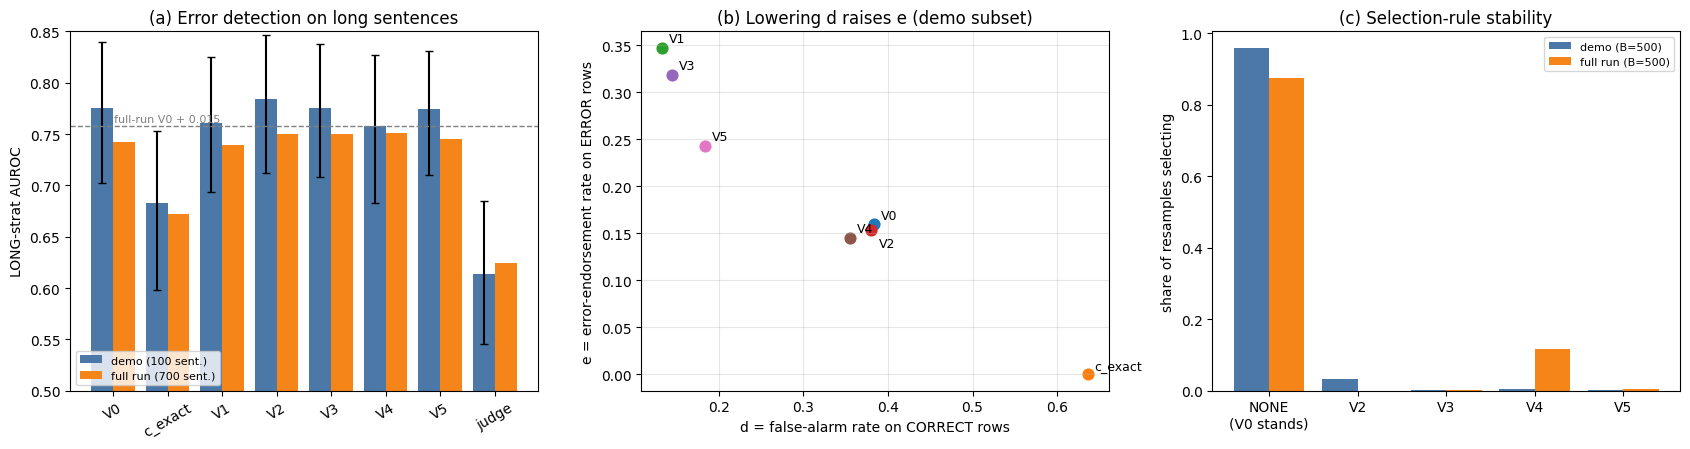

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
order = ["V0_frozen", "c_exact", "V1", "V2", "V3", "V4", "V5", "judge_cheap_disg"]
labels = ["V0", "c_exact", "V1", "V2", "V3", "V4", "V5", "judge"]

# (a) LONG-strat AUROC: demo (with bootstrap CI) vs full run
ax = axes[0]
x = np.arange(len(order))
demo = [A["auroc"]["LONG-strat"][s]["auroc"] for s in order]
lo = [A["auroc"]["LONG-strat"][s]["ci"][0] for s in order]
hi = [A["auroc"]["LONG-strat"][s]["ci"][1] for s in order]
ax.bar(x - 0.2, demo, 0.4, yerr=[np.array(demo) - lo, np.array(hi) - demo], capsize=3, label=f"demo ({N_SENTENCES} sent.)", color="#4C78A8")
ax.bar(x + 0.2, [ref["LONG_strat_auroc"][s] for s in order], 0.4, label="full run (700 sent.)", color="#F58518")
ax.axhline(ref["LONG_strat_auroc"]["V0_frozen"] + MARGIN, ls="--", c="grey", lw=1)
ax.text(1, ref["LONG_strat_auroc"]["V0_frozen"] + MARGIN + 0.004, "full-run V0 + 0.015", ha="center", fontsize=8, color="grey")
ax.set_xticks(x, labels, rotation=30)
ax.set_ylim(0.5, 0.85)
ax.set_ylabel("LONG-strat AUROC")
ax.set_title("(a) Error detection on long sentences")
ax.legend(fontsize=8, loc="lower left")

# (b) e vs d trade-off (ALL rows of Z)
ax = axes[1]
for s, lab in zip(SCORES, ["V0", "V0_rep", "c_exact"] + VARIANTS):
    if s == "V0_rep":
        continue
    ax.scatter(A["ed"]["ALL"][s]["d"], A["ed"]["ALL"][s]["e"], s=60)
    ax.annotate(lab, (A["ed"]["ALL"][s]["d"], A["ed"]["ALL"][s]["e"]), textcoords="offset points",
                xytext=(5, -12) if s == "V2" else (5, 4), fontsize=9)
ax.set_xlabel("d = false-alarm rate on CORRECT rows")
ax.set_ylabel("e = error-endorsement rate on ERROR rows")
ax.set_title("(b) Lowering d raises e (demo subset)")
ax.grid(alpha=0.3)

# (c) selection stability (demo) vs full run
ax = axes[2]
keys = sorted(set(sel["stability"]["share_selected"]) | set(ref["part_A_stability"]["share_selected"]))
xs = np.arange(len(keys))
ax.bar(xs - 0.2, [sel["stability"]["share_selected"].get(k, 0) for k in keys], 0.4, label=f"demo (B={B_STAB})", color="#4C78A8")
ax.bar(xs + 0.2, [ref["part_A_stability"]["share_selected"].get(k, 0) for k in keys], 0.4, label="full run (B=500)", color="#F58518")
ax.set_xticks(xs, [k.replace(": V0 stands", "\n(V0 stands)") for k in keys])
ax.set_ylabel("share of resamples selecting")
ax.set_title("(c) Selection-rule stability")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**How to read this.** In the full run, no label-free rescoring beats V0 by the pre-registered margin on long,
heavily conditioned sentences, so **V0 stands** (87.6% of stability resamples agree). Panel (b) shows why:
plurality normalisation (V1/V3/V5) cuts false alarms **d** by endorsing more errors (**e** rises). This is sharpest
for MEANING_RENAME-type errors. None of the variants lowers d without raising e. On a 100-sentence subset the AUROC
CIs are wide, so the demo's decision and stability shares can differ from the full run. Increase `N_SENTENCES` or
run the original pipeline on all 700 sentences for the real numbers.